# Cross-validation per la stima degli iperparametri 

*Docenti*: Luca Calatroni, Lorenzo Rosasco

In questa lezione usiamo la cross-validation per scegliere gli iperparametri di due modelli di classificazione:

1. **modello lineare con loss quadratica** (`RidgeClassifier`);
2. **albero decisionale** (`DecisionTreeClassifier`).

In [1]:
# Import delle librerie

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## 1. Dataset

Usiamo il dataset Breast Cancer: classificazione binaria, feature numeriche, dataset già pulito.


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Classi:", data.target_names)

print("\nDistribuzione classi:")
for label, name in enumerate(data.target_names):
    print(name, ":", np.sum(y == label))


Shape X: (569, 30)
Shape y: (569,)
Classi: ['malignant' 'benign']

Distribuzione classi:
malignant : 212
benign : 357


In [3]:
# TO DO: Lasciamo da parte l'insieme test e creiamo X_temp e y_temp, rispettando la proporzione tra le classi

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_temp:", X_temp.shape)
print("X_test:", X_test.shape)


X_temp: (455, 30)
X_test: (114, 30)


Definiamo gli split utilizzando `StratifiedKFold` perché vogliamo mantenere proporzioni simili tra le classi.

In [4]:
# TO DO: definire gli split che verranno utilizzati in cross validation, introdurre shuffling 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 2. CV per selezione dei parametri in RidgeClassifier

Definiamo la pipeline per RidgeClassifier, includendo lo scaling dei dati. 
Definiamo poi un vettore di parametri $\alpha$ che verranno testati tramite CV.


In [5]:
# TO DO: definire la pipeline per il ridgeClassifier, aggiungendo scaling

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeClassifier())
])

# Definiamo i parametri $\alpha$ da testare

ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
}

# Routine di grid search tramite cross validation del parametro ottimale

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)


# TO DO: trainare sull'insieme non test

ridge_grid.fit(X_temp,y_temp)

print("Migliori parametri RidgeClassifier:")
print(ridge_grid.best_params_)
print("Miglior accuracy media in CV:", ridge_grid.best_score_)


Migliori parametri RidgeClassifier:
{'model__alpha': 0.5}
Miglior accuracy media in CV: 0.9516483516483516


Visualizziamo i risultati.

Gli score riportati sono medie e deviazioni standard sui fold della cross-validation.


mean=0.949, std=0.023, params={'model__alpha': 0.001}
mean=0.949, std=0.023, params={'model__alpha': 0.01}
mean=0.949, std=0.023, params={'model__alpha': 0.1}
mean=0.952, std=0.020, params={'model__alpha': 0.5}
mean=0.949, std=0.023, params={'model__alpha': 1.0}
mean=0.947, std=0.021, params={'model__alpha': 10.0}
mean=0.949, std=0.015, params={'model__alpha': 100.0}


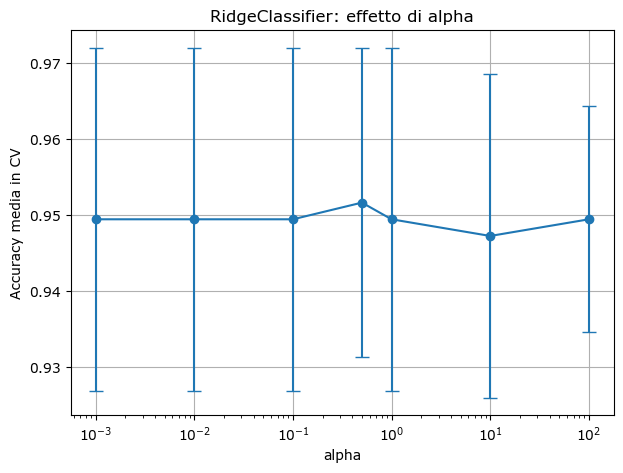

In [6]:
ridge_results = ridge_grid.cv_results_

for mean, std, params in zip(
    ridge_results["mean_test_score"],
    ridge_results["std_test_score"],
    ridge_results["params"]
):
    print(f"mean={mean:.3f}, std={std:.3f}, params={params}")

alphas = ridge_param_grid["model__alpha"]
plt.figure(figsize=(7, 5))
plt.errorbar(alphas, ridge_results["mean_test_score"], yerr=ridge_results["std_test_score"], marker="o", capsize=5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Accuracy media in CV")
plt.title("RidgeClassifier: effetto di alpha")
plt.grid(True)
plt.show()


## 3. CV per selezione parametri in Decision Trees

Consideriamo due iperparametri:

- `max_depth`: profondità massima dell'albero;
- `min_samples_leaf`: numero minimo di campioni in una foglia.

Entrambi controllano la complessità del modello.


In [8]:
# Definiamo la pipeline (non è necessario lo scaling qui)

tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

# TO DO: Definiamo i parametri su cui verrà fatta grid-search

tree_param_grid = {
    "model__max_depth": [2, 3, 5, 10, None], # scegliere interi o None
    "model__min_samples_leaf":  [1, 2, 5, 10]# scegliere interi
}


# TO DO: impostare la procedure di CV

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

tree_grid.fit(X_temp, y_temp)

print("Migliori parametri DecisionTreeClassifier:")
print(tree_grid.best_params_)
print("Miglior accuracy media in CV:", tree_grid.best_score_)


Migliori parametri DecisionTreeClassifier:
{'model__max_depth': 5, 'model__min_samples_leaf': 1}
Miglior accuracy media in CV: 0.9406593406593406


Visualizziamo i risultati.

In [9]:
tree_results = tree_grid.cv_results_

for mean, std, params in zip(
    tree_results["mean_test_score"],
    tree_results["std_test_score"],
    tree_results["params"]
):
    print(f"mean={mean:.3f}, std={std:.3f}, params={params}")


mean=0.912, std=0.029, params={'model__max_depth': 2, 'model__min_samples_leaf': 1}
mean=0.912, std=0.029, params={'model__max_depth': 2, 'model__min_samples_leaf': 2}
mean=0.912, std=0.029, params={'model__max_depth': 2, 'model__min_samples_leaf': 5}
mean=0.912, std=0.029, params={'model__max_depth': 2, 'model__min_samples_leaf': 10}
mean=0.932, std=0.025, params={'model__max_depth': 3, 'model__min_samples_leaf': 1}
mean=0.934, std=0.023, params={'model__max_depth': 3, 'model__min_samples_leaf': 2}
mean=0.934, std=0.024, params={'model__max_depth': 3, 'model__min_samples_leaf': 5}
mean=0.919, std=0.023, params={'model__max_depth': 3, 'model__min_samples_leaf': 10}
mean=0.941, std=0.026, params={'model__max_depth': 5, 'model__min_samples_leaf': 1}
mean=0.934, std=0.026, params={'model__max_depth': 5, 'model__min_samples_leaf': 2}
mean=0.932, std=0.025, params={'model__max_depth': 5, 'model__min_samples_leaf': 5}
mean=0.916, std=0.025, params={'model__max_depth': 5, 'model__min_samples_

### Effetto di `max_depth`

Per visualizzare su un grafico l'accuracy media e le barre d'errore fissiamo `min_samples_leaf=1`, che abbiamo visto essere il valore ottimale.


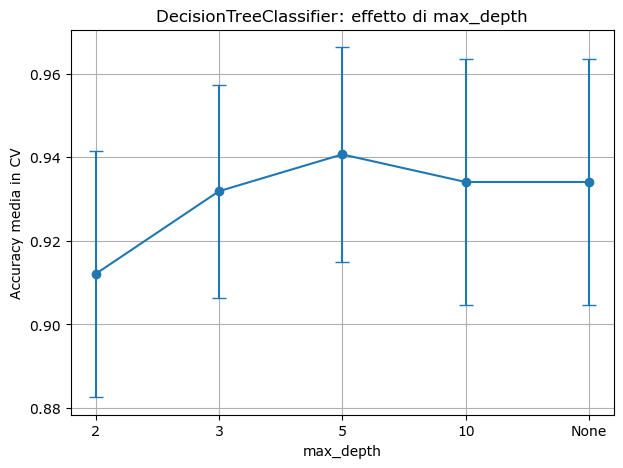

In [11]:
depths = tree_param_grid["model__max_depth"]
depth_labels = [str(d) for d in depths]

means = []
stds = []

# TO DO: creare il vettore contenente le medie e quello contenente le standard deviation

for depth in depths:
    for p, mean, std in zip(
        tree_results["params"],
        tree_results["mean_test_score"],
        tree_results["std_test_score"],
    ):
        if p["model__max_depth"] == depth and p["model__min_samples_leaf"] == 1:
            means.append(mean)
            stds.append(std)
            break

plt.figure(figsize=(7, 5))
plt.errorbar(depth_labels, means, yerr=stds, marker="o", capsize=5)
plt.xlabel("max_depth")
plt.ylabel("Accuracy media in CV")
plt.title("DecisionTreeClassifier: effetto di max_depth")
plt.grid(True)
plt.show()

## 4. Confronto tra modelli ottimali

Confrontiamo i migliori modelli selezionati dalla cross-validation su `X_temp, y_temp`.


In [12]:
print("RidgeClassifier")
print("best params:", ridge_grid.best_params_)
print("best CV accuracy:", ridge_grid.best_score_)

print("\nDecisionTreeClassifier")
print("best params:", tree_grid.best_params_)
print("best CV accuracy:", tree_grid.best_score_)

model_names = ["RidgeClassifier", "DecisionTree"]
best_cv_scores = [ridge_grid.best_score_, tree_grid.best_score_]

RidgeClassifier
best params: {'model__alpha': 0.5}
best CV accuracy: 0.9516483516483516

DecisionTreeClassifier
best params: {'model__max_depth': 5, 'model__min_samples_leaf': 1}
best CV accuracy: 0.9406593406593406


Scegliamo il modello con accuracy media in cross-validation più alta. Questa scelta non usa il test set.


In [13]:
# TO DO: selezione modello

if ridge_grid.best_score_>tree_grid.best_score_:
    final_model_name = "RidgeClassifier"
    final_model = ridge_grid.best_estimator_
else:
    final_model_name = "DecisionTreeClassifier"
    final_model = tree_grid.best_estimator_

print("Modello finale scelto:", final_model_name)


Modello finale scelto: RidgeClassifier


## 5. Test finale

Ora usiamo il test set una sola volta. `best_estimator_` è già stato riaddestrato da `GridSearchCV` su tutto `X_temp, y_temp` con i migliori iperparametri.


In [15]:
# TO DO

y_test_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test,y_test_pred)

print("Modello finale:", final_model_name)
print("Test accuracy:", test_acc)


Modello finale: RidgeClassifier
Test accuracy: 0.956140350877193


Visualizzazione della matrice di confusione sul test set.

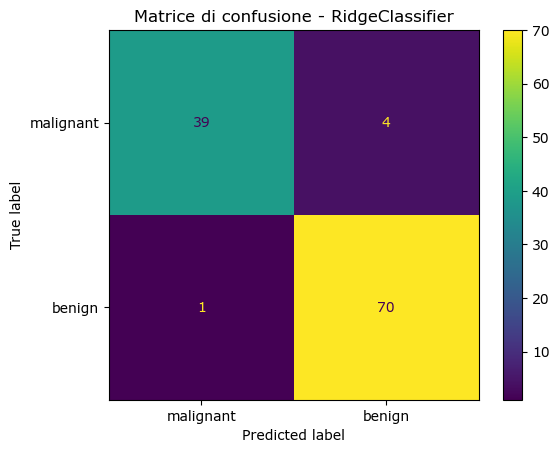

Accuracy dalla matrice di confusione: 0.956140350877193


In [16]:
# TO DO: creare e generare le matrice di confusione

cm = confusion_matrix(y_test,y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot()
plt.title(f"Matrice di confusione - {final_model_name}")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Accuracy dalla matrice di confusione:", (tp + tn) / cm.sum())